# EDA

En este Notebook vamos a ilustrar un Exploratory Data Analysis (EDA)

In [1]:
# === Datos ===
DATA_URL = "https://raw.githubusercontent.com/aaleta/cex_2026/main/2_analisis/data/"

import os, urllib.request
def datos(nombre):
    if not os.path.exists(nombre) and DATA_URL:
        urllib.request.urlretrieve(DATA_URL + nombre, nombre)
    if not os.path.exists(nombre):
        raise FileNotFoundError(f"Falta '{nombre}': súbelo a Colab o define DATA_URL")
    return nombre

for _f in ['StudentsPerformance.csv']:
    datos(_f)
print('Datos listos:', 'StudentsPerformance.csv')

Datos listos: StudentsPerformance.csv


## Paso 1: Abrimos el archivo y vemos qué hay


In [2]:
import pandas as pd

df = pd.read_csv('StudentsPerformance.csv')

df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


1000 filas y 8 columnas.

Entre las columnas tenemos:

- Categóricas: gender, race/ethnicity, parental level of education, lunch, test preparation course
- Numéricas: math score, reading score y writing score

Miramos también los tipos, y valores nulos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Vamos a mirar también qué opcion

Nota: Aquí no hay cosas raras porque esto ya son datos limpios. Si no, en el proceso de limpieza también nos habríamos ido acostumbrando a estos datos.

### Medidas de tendencia central

¿Cuáles son las notas más comunes, la media, ...?

In [ ]:
print("Nota media en matemáticas: ", df['math score'].mean())
print("Nota media en lectura: ", df['reading score'].mean())
print("Nota media en escritura: ", df['writing score'].mean())

Nota media en matemáticas:  66.089
Nota media en lectura:  69.169
Nota media en escritura:  68.054


In [ ]:
print("Nota mediana en matemáticas: ", df['math score'].median())
print("Nota mediana en lectura: ", df['reading score'].median())
print("Nota mediana en escritura: ", df['writing score'].median())

Nota mediana en matemáticas:  66.0
Nota mediana en lectura:  70.0
Nota mediana en escritura:  69.0


Con las variables categóricas podemos contar valores, por ejemplo:

In [ ]:
df['parental level of education'].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [ ]:
df['test preparation course'].value_counts()

test preparation course
none         642
completed    358
Name: count, dtype: int64

In [ ]:
df['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

### Medidas de dispersión

In [ ]:
print("Nota más baja en matemáticas: ", df['math score'].min())
print("Nota más alta en matemáticas: ", df['math score'].max())
print("-------")
print("Nota más baja en lectura: ", df['reading score'].min())
print("Nota más alta en lectra: ", df['reading score'].max())
print("-------")
print("Nota más baja en escritura: ", df['writing score'].min())
print("Nota más alta en escritura: ", df['writing score'].max())
print("-------")

Nota más baja en matemáticas:  0
Nota más alta en matemáticas:  100
-------
Nota más baja en lectura:  17
Nota más alta en lectra:  100
-------
Nota más baja en escritura:  10
Nota más alta en escritura:  100
-------


In [ ]:
print("Desviación típica en matemáticas: ", df['math score'].std())
print("Desviación típica en lectura: ", df['reading score'].std())
print("Desviación típica en escritura: ", df['writing score'].std())

Desviación típica en matemáticas:  15.16308009600945
Desviación típica en lectura:  14.600191937252216
Desviación típica en escritura:  15.19565701086965


Otras medidas como el rango intercuartil ya no son tan inmediatas (pero tampoco es tan complicado)

In [ ]:
quartiles = df['math score'].quantile([0.25, 0.75])
iqr = quartiles[0.75] - quartiles[0.25]
print(iqr)

20.0


### Pintando distribuciones

Siempre es mejor pintar lo que se pueda

<Axes: >

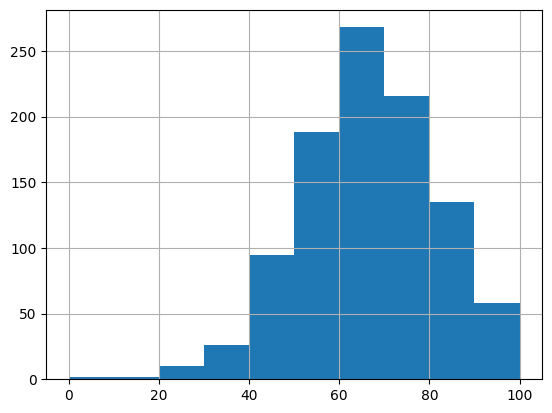

In [4]:
## Vamos a ver como se distribuyen las notas de matemáticas
df["math score"].hist()

In [5]:
## O con plotly express

import plotly.express as px

fig = px.histogram(df, x="math score")
fig.show()

Para variables categóricas podríamos representar un pie chart (adecuado solo si el número de opciones es bajo)

In [11]:
df_pie = pd.DataFrame(df['parental level of education'].value_counts())
df_pie

,count
parental level of education,
some college,226
associate's degree,222
high school,196
some high school,179
bachelor's degree,118
master's degree,59


In [12]:

df_pie = df_pie.reset_index()
df_pie = df_pie.rename(columns={
    'index': 'parental level of education'}
)

fig = px.pie(df_pie, values='count', names='parental level of education')
fig.show()

### Medidas de posición relativa

Puede ser más útil saber tu nota en relación con el resto de la clase...

Standard score:

$Z = \frac{x - \mu}{σ}$

donde:

$\mu$ es la media

$σ$ es la varianza

Vamos a calcular unas columnas adicionales con el standard score de cada tipo de examen

In [ ]:
cols = ['math score', 'reading score', 'writing score']

for col in cols:
  new_col = 'standard ' + col
  df[new_col] = (df[col] - df[col].mean())/df[col].std()

df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,standard math score,standard reading score,standard writing score
0,female,group B,bachelor's degree,standard,none,72,72,74,0.389828,0.193902,0.391296
1,female,group C,some college,standard,completed,69,90,88,0.191979,1.426762,1.312612
2,female,group B,master's degree,standard,none,90,95,93,1.576922,1.769223,1.641653
3,male,group A,associate's degree,free/reduced,none,47,57,44,-1.258913,-0.833482,-1.582952
4,male,group C,some college,standard,none,76,78,75,0.653627,0.604855,0.457104
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,1.445023,2.043192,1.773270
996,male,group C,high school,free/reduced,none,62,55,55,-0.269668,-0.970467,-0.859061
997,female,group C,high school,free/reduced,completed,59,71,65,-0.467517,0.125409,-0.200978
998,female,group D,some college,standard,completed,68,78,77,0.126030,0.604855,0.588721


## Correlación entre variables

### Entre una variable categórica y una numérica

Con los groupby podemos obtener las medias, medianas, etc para diferentes grupos

Por ejemplo, podemos ver las notas medias por nivel de educación de los padres

In [13]:
df_group = df.groupby(['parental level of education']).agg(
    {'math score': 'mean',
     'reading score': 'mean',
     'writing score': 'mean'})
df_group

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


Podemos separarnos nuestra población de alumnos por cada uno de las categorías e "parent level of education" y ver esas distribuciones (por ejemplo con un boxplot)

In [14]:
## Plot a boxplot
import plotly.express as px

fig = px.box(df, x="parental level of education", y="math score")
fig.show()

O si tenemos menos categorías, quizá podemos pintar dos distribuciones juntas

In [15]:
fig = px.histogram(df, x="math score", color = "test preparation course", marginal="rug",
                   barmode='overlay', histnorm='probability density', hover_data=df.columns)
fig.show()

Podemos poner un boxplot arriba también...

In [16]:
fig = px.histogram(df, x="math score", color = "test preparation course", marginal="box",
                   barmode='overlay', histnorm='probability density', hover_data=df.columns)
fig.show()

### Entre dos variables numéricas

¿Están correlacionadas las notas entre distintos tipos de examen?

Lo más fácil que podemos hacer es coger dos variables númericas, poner una en el eje X, otra en el Y; y situar cada alumno en ese mapa con un punto (Scatter Plot)

In [17]:
fig = px.scatter(df, x="math score", y="reading score")
fig.show()

In [20]:
fig = px.scatter(
    df, x="math score", y="reading score",
    marginal_x="box", marginal_y="box",
    trendline="ols", width=700, height=700
)
fig.show()

In [22]:
fig = px.density_heatmap(
    df, x="math score", y="reading score",
    nbinsx=100, nbinsy=83, marginal_x='violin', marginal_y='violin',
    width=700, height=700, color_continuous_scale=['lightblue', 'darkred'])
fig.show()

Si no hubiera correlación, tendríamos una nube de puntos que cubriría homogeneamente todo. No es el caso, a mayor nota en matemáticas, mayor nota en lectura.

El grado de correlación entre dos variables puede resumirse en un único número (aunque existen diferentes coeficientes). Así, podemos sacar una matriz de correlación entre todas nuestras variables numéricas.

In [24]:
df[['math score','reading score','writing score']].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


### Relación entre dos variables categóricas

In [25]:
table = pd.pivot_table(df, values='math score', index=['gender'],
                       columns=['test preparation course'], aggfunc='count')

table

test preparation course,completed,none
gender,,
female,184,334
male,174,308


In [27]:
import plotly.express as px

# Reset index to make 'gender' a regular column for plotting
table_reset = table.reset_index()

# Melt the DataFrame to have 'test preparation course' as a column
table_melted = table_reset.melt(
    id_vars=['gender'],
    value_vars=['completed', 'none'],
    var_name='test preparation course',
    value_name='count'
)

# Plotting the pivot table as a bar chart
fig = px.bar(
    table_melted,
    x='gender',
    y='count',
    color='test preparation course',
    barmode='group',
    title='Count of Students by Gender and Test Preparation Course'
)
fig.show()

## Combinando variables

In [23]:
fig = px.scatter(
    df, x="math score", y="reading score",
    marginal_x="box", marginal_y="box",
    trendline="ols", width=700, height=700,
    color = 'gender'
)
fig.show()

... pero cuidado con pasarse

In [30]:
fig = px.scatter(
    df, x="math score", y="reading score",
    marginal_x="box", marginal_y="box",
    trendline="ols", width=700, height=700,
    color='gender', # Tercera variable
    symbol='test preparation course' # Cuarta variable
)
fig.update_layout(title='Notas de Matemáticas vs Lectura por Género y Curso de Preparación')
fig.show()

También podemos usar facetado para ver la distribución en subgráficos separados por una variable categórica adicional. Por ejemplo, viendo las notas de matemáticas por género, separadas por el nivel educativo de los padres:

In [38]:
fig = px.box(
    df, x="gender", y="math score",
    color="gender", # Primera variable categórica
    facet_col="parental level of education", # Segunda variable categórica para facetas
    facet_col_wrap=2, # Distribute facets into 2 rows (6 facets / 3 cols = 2 rows)
    title='Distribución de Notas de Matemáticas por Género y Nivel Educativo de los Padres',
    height=800
)

fig.show()

## Visualizaciones avanzadas

### Ridgelines

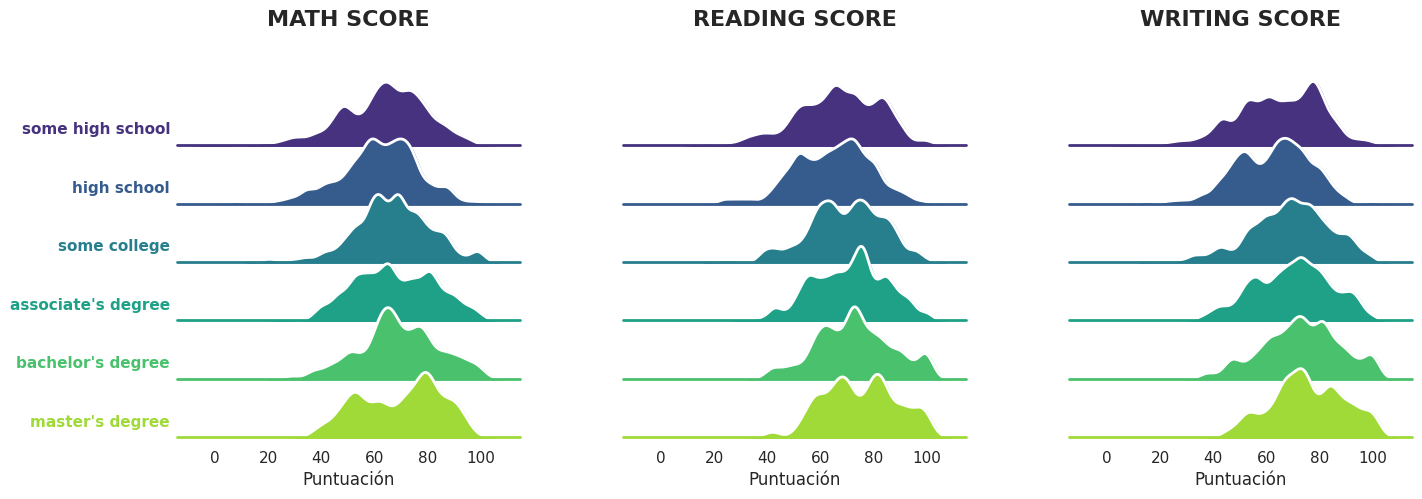

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_features = ['math score', 'reading score', 'writing score']

# Definir el orden deseado para 'parental level of education'
education_order = [
    'some high school',
    'high school',
    'some college',
    'associate\'s degree',
    'bachelor\'s degree',
    'master\'s degree'
]

# Asegurarse de que la columna esté en tipo 'category' con el orden especificado
df['parental level of education'] = pd.Categorical(
    df['parental level of education'],
    categories=education_order,
    ordered=True
)

# Preparar los datos para el ridgeline plot (derretir el DataFrame)
df_melted_education = df.melt(
    id_vars=['parental level of education'],
    value_vars=numerical_features,
    var_name='subject',
    value_name='score'
)

# Configuramos el estilo para ridgeline
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Ajustamos el aspect y el espacio horizontal
g = sns.FacetGrid(df_melted_education, row="parental level of education", col="subject",
                  hue="parental level of education", aspect=6, height=0.8, palette="viridis")

# Dibujamos las densidades
g.map(sns.kdeplot, "score", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "score", clip_on=False, color="w", lw=2, bw_adjust=.5)

g.map(plt.axhline, y=0, lw=2, clip_on=False)

# Función de etiquetas modificada para mostrarse solo en la columna 0
def label(x, color, label):
    ax = plt.gca()
    # Solo dibujamos la etiqueta si el eje está en la primera columna
    if ax.get_subplotspec().is_first_col():
        ax.text(-0.02, .2, label, fontweight="bold", color=color,
                ha="right", va="center", transform=ax.transAxes, fontsize=11)

g.map(label, "score")

# Ajustamos el solapamiento vertical y el espacio entre columnas
g.fig.subplots_adjust(hspace=-0.25, wspace=0.3)

# Limpieza de ejes
g.set_titles("")
g.set(yticks=[], ylabel="", xlabel="Puntuación")
g.despine(bottom=True, left=True)

# Títulos de las asignaturas
for ax, title in zip(g.axes[0], numerical_features):
    ax.set_title(title.upper(), fontweight='bold', fontsize=16, pad=30)

plt.show()

### Correlograms

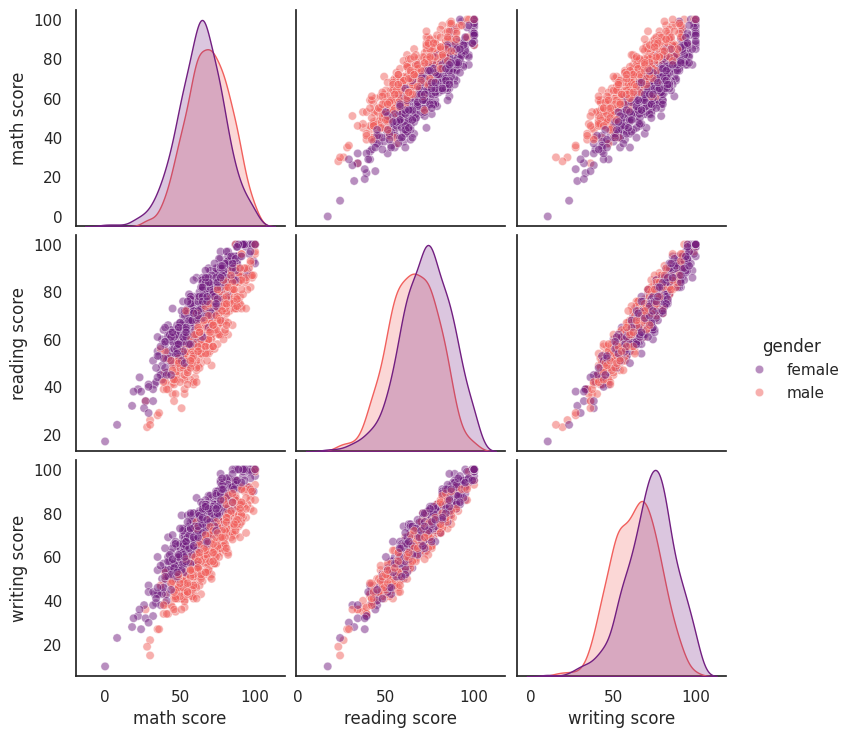

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear el correlograma (pairplot)
# Usamos 'gender' como hue para añadir una capa adicional de análisis visual
g = sns.pairplot(df[numerical_features + ['gender']], hue='gender', palette='magma', diag_kind='kde', plot_kws={'alpha': 0.5})

# Título superior eliminado a petición del usuario

plt.show()

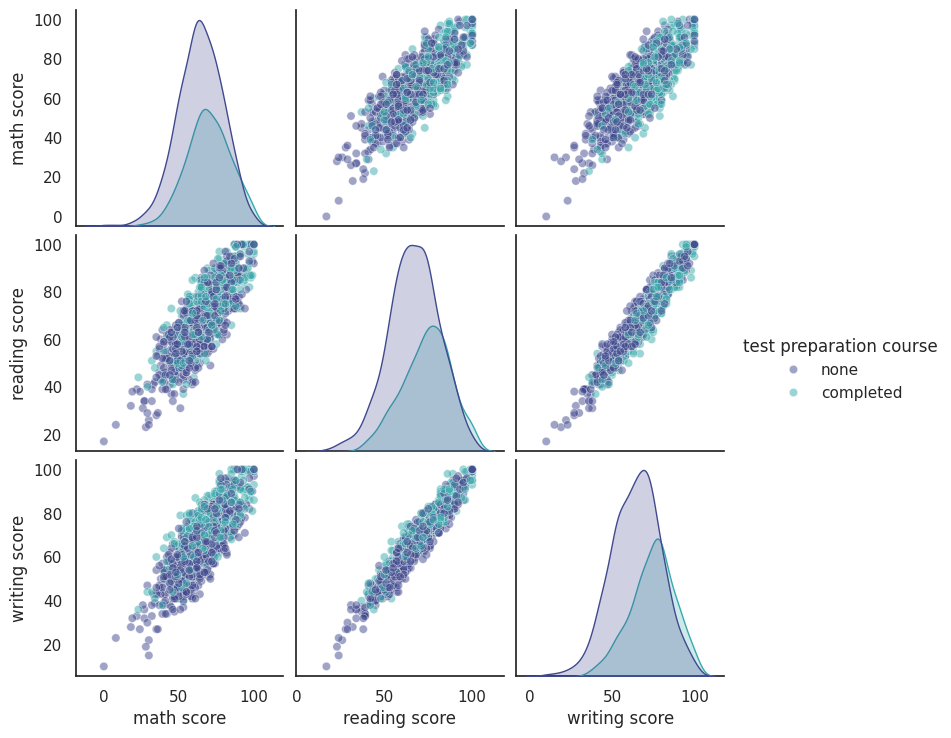

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear el correlograma (pairplot)
# Usamos 'gender' como hue para añadir una capa adicional de análisis visual
g = sns.pairplot(df[numerical_features + ['test preparation course']], hue='test preparation course', palette='mako', diag_kind='kde', plot_kws={'alpha': 0.5})

# Título superior eliminado a petición del usuario

plt.show()